In [8]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, DataStructs
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv('nr_ic_merged.csv')

In [10]:
# Keep only valid SMILES
def smiles_to_mol(s):
    if pd.isna(s) or str(s).lower() == 'nan':
        return None
    try:
        return Chem.MolFromSmiles(str(s))
    except Exception:
        return None

df['mol'] = df['Smiles'].map(smiles_to_mol)
df = df[df['mol'].notna()].copy()

# Keep only rows with target values
df = df[df['pChEMBL Value'].notna()].copy()

In [11]:
df

,Unnamed: 0,Molecule ChEMBL ID,Molecule Name,Smiles,Standard Type,Standard Value,Standard Units,pChEMBL Value,Target,mol
0,0,CHEMBL390728,NaN,CCC1CCNc2cc3[nH]c(=O)cc(C(F)(F)F)c3cc21,IC50,4580.0,nM,5.34,ar,<rdkit.Chem.rdchem.Mol object at 0x7f47f9947df0>
1,1,CHEMBL3936931,NaN,O=C(N[C@H]1CC[C@H](Oc2ccnc3c(Br)cccc23)CC1)c1c...,IC50,190.0,nM,6.72,ar,<rdkit.Chem.rdchem.Mol object at 0x7f47f8fe4510>
2,2,CHEMBL418684,NaN,CC1=CC(C)(C)Nc2ccc3c(c21)COc1c(F)cc(F)cc1-3,IC50,644.0,nM,6.19,ar,<rdkit.Chem.rdchem.Mol object at 0x7f47f8fe45f0>
3,3,CHEMBL235126,NaN,O=c1cc(O)c2cc(N(CC(F)(F)F)CC(F)(F)F)ccc2[nH]1,IC50,7.0,nM,8.15,ar,<rdkit.Chem.rdchem.Mol object at 0x7f47f8fe4660>
4,4,CHEMBL266491,NaN,COCCOc1ccccc1-c1ccc(C#N)c(C(F)(F)F)c1,IC50,2230.0,nM,5.65,ar,<rdkit.Chem.rdchem.Mol object at 0x7f47f8fe46d0>
...,...,...,...,...,...,...,...,...,...,...
14168,14168,CHEMBL118963,NaN,O=C1Nc2ccc(-c3cccc(Cl)c3)cc2C12CCCC2,IC50,32.0,nM,7.50,pr,<rdkit.Chem.rdchem.Mol object at 0x7f47f8d6ed50>
14169,14169,CHEMBL117461,NaN,N#Cc1cc(F)cc(-c2ccc3c(c2)C2(CCCC2)C(=O)N3)c1,IC50,13.2,nM,7.88,pr,<rdkit.Chem.rdchem.Mol object at 0x7f47f8d6edc0>
14170,14170,CHEMBL117322,NaN,CC1C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,30.6,nM,7.51,pr,<rdkit.Chem.rdchem.Mol object at 0x7f47f8d6ee30>
14171,14171,CHEMBL119058,NaN,CC1(C)C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,102.0,nM,6.99,pr,<rdkit.Chem.rdchem.Mol object at 0x7f47f8d6eea0>


In [12]:
FPSIZE = 2048
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=FPSIZE)


def mol_to_fp(mol):
    fp = morgan_gen.GetFingerprint(mol)
    arr = np.zeros((FPSIZE,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr


df['fp'] = df['mol'].map(mol_to_fp)

In [13]:
df

,Unnamed: 0,Molecule ChEMBL ID,Molecule Name,Smiles,Standard Type,Standard Value,Standard Units,pChEMBL Value,Target,mol,fp
0,0,CHEMBL390728,NaN,CCC1CCNc2cc3[nH]c(=O)cc(C(F)(F)F)c3cc21,IC50,4580.0,nM,5.34,ar,<rdkit.Chem.rdchem.Mol object at 0x7f47f9947df0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,1,CHEMBL3936931,NaN,O=C(N[C@H]1CC[C@H](Oc2ccnc3c(Br)cccc23)CC1)c1c...,IC50,190.0,nM,6.72,ar,<rdkit.Chem.rdchem.Mol object at 0x7f47f8fe4510>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ..."
2,2,CHEMBL418684,NaN,CC1=CC(C)(C)Nc2ccc3c(c21)COc1c(F)cc(F)cc1-3,IC50,644.0,nM,6.19,ar,<rdkit.Chem.rdchem.Mol object at 0x7f47f8fe45f0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,3,CHEMBL235126,NaN,O=c1cc(O)c2cc(N(CC(F)(F)F)CC(F)(F)F)ccc2[nH]1,IC50,7.0,nM,8.15,ar,<rdkit.Chem.rdchem.Mol object at 0x7f47f8fe4660>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,4,CHEMBL266491,NaN,COCCOc1ccccc1-c1ccc(C#N)c(C(F)(F)F)c1,IC50,2230.0,nM,5.65,ar,<rdkit.Chem.rdchem.Mol object at 0x7f47f8fe46d0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
...,...,...,...,...,...,...,...,...,...,...,...
14168,14168,CHEMBL118963,NaN,O=C1Nc2ccc(-c3cccc(Cl)c3)cc2C12CCCC2,IC50,32.0,nM,7.50,pr,<rdkit.Chem.rdchem.Mol object at 0x7f47f8d6ed50>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
14169,14169,CHEMBL117461,NaN,N#Cc1cc(F)cc(-c2ccc3c(c2)C2(CCCC2)C(=O)N3)c1,IC50,13.2,nM,7.88,pr,<rdkit.Chem.rdchem.Mol object at 0x7f47f8d6edc0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
14170,14170,CHEMBL117322,NaN,CC1C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,30.6,nM,7.51,pr,<rdkit.Chem.rdchem.Mol object at 0x7f47f8d6ee30>,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ..."
14171,14171,CHEMBL119058,NaN,CC1(C)C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,102.0,nM,6.99,pr,<rdkit.Chem.rdchem.Mol object at 0x7f47f8d6eea0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [14]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
target_encoded = encoder.fit_transform(df[['Target']])

print(target_encoded.shape)
print(encoder.get_feature_names_out(['Target']))

(14164, 6)
['Target_ar' 'Target_era' 'Target_erb' 'Target_gr' 'Target_mr' 'Target_pr']


In [15]:
df

,Unnamed: 0,Molecule ChEMBL ID,Molecule Name,Smiles,Standard Type,Standard Value,Standard Units,pChEMBL Value,Target,mol,fp
0,0,CHEMBL390728,NaN,CCC1CCNc2cc3[nH]c(=O)cc(C(F)(F)F)c3cc21,IC50,4580.0,nM,5.34,ar,<rdkit.Chem.rdchem.Mol object at 0x7f47f9947df0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,1,CHEMBL3936931,NaN,O=C(N[C@H]1CC[C@H](Oc2ccnc3c(Br)cccc23)CC1)c1c...,IC50,190.0,nM,6.72,ar,<rdkit.Chem.rdchem.Mol object at 0x7f47f8fe4510>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ..."
2,2,CHEMBL418684,NaN,CC1=CC(C)(C)Nc2ccc3c(c21)COc1c(F)cc(F)cc1-3,IC50,644.0,nM,6.19,ar,<rdkit.Chem.rdchem.Mol object at 0x7f47f8fe45f0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,3,CHEMBL235126,NaN,O=c1cc(O)c2cc(N(CC(F)(F)F)CC(F)(F)F)ccc2[nH]1,IC50,7.0,nM,8.15,ar,<rdkit.Chem.rdchem.Mol object at 0x7f47f8fe4660>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,4,CHEMBL266491,NaN,COCCOc1ccccc1-c1ccc(C#N)c(C(F)(F)F)c1,IC50,2230.0,nM,5.65,ar,<rdkit.Chem.rdchem.Mol object at 0x7f47f8fe46d0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
...,...,...,...,...,...,...,...,...,...,...,...
14168,14168,CHEMBL118963,NaN,O=C1Nc2ccc(-c3cccc(Cl)c3)cc2C12CCCC2,IC50,32.0,nM,7.50,pr,<rdkit.Chem.rdchem.Mol object at 0x7f47f8d6ed50>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
14169,14169,CHEMBL117461,NaN,N#Cc1cc(F)cc(-c2ccc3c(c2)C2(CCCC2)C(=O)N3)c1,IC50,13.2,nM,7.88,pr,<rdkit.Chem.rdchem.Mol object at 0x7f47f8d6edc0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
14170,14170,CHEMBL117322,NaN,CC1C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,30.6,nM,7.51,pr,<rdkit.Chem.rdchem.Mol object at 0x7f47f8d6ee30>,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ..."
14171,14171,CHEMBL119058,NaN,CC1(C)C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,102.0,nM,6.99,pr,<rdkit.Chem.rdchem.Mol object at 0x7f47f8d6eea0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [16]:
x = np.vstack(df['fp'].values)
x_combined = np.hstack([x, target_encoded])
y = df['pChEMBL Value'].values

In [17]:
x_train, x_test, y_train, y_test = train_test_split(
    x_combined, y, test_size=0.2, random_state=42
)

In [18]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
model.fit(x_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
y_pred = model.predict(x_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))


print(f"R² = {r2:.3f}")
print(f"RMSE = {rmse:.3f}")

R² = 0.676
RMSE = 0.712


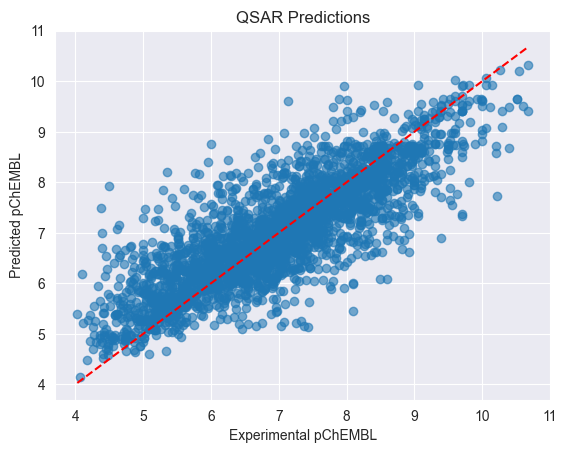

In [20]:
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Experimental pChEMBL")
plt.ylabel("Predicted pChEMBL")
plt.title("QSAR Predictions")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.show()